# 🎯 Corner Kick Modeling: Two-Stage Hierarchical XGBoost Architecture

In this experiment, we explore, analyze, and model **Corner Kicks** across the World Cup dataset using a specialized **Two-Stage Tree-Based Framework**:
1. **Exploratory Data Analysis (EDA) & Pattern Identification**: Uncovering spatial crossing geometries, routine frequencies, and scoring conversion rates.
2. **Feature Extraction & Importance Analysis**: Identifying the critical physical, technical, and tactical drivers of corner kick outcomes.
3. **Two-Stage Model Training**:
   - **Stage 1**: 3-Class XGBoost Routine Classifier (`Direct Central Cross`, `Post Cross`, `Short Corner`).
   - **Stage 2**: Binary XGBoost Outcome Classifier (`Attacking Success` vs. `Defensive Success`).
4. **Stochastic Simulation & Accuracy Evaluation**: Simulating corner routines and outcomes to evaluate predictive performance.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Setup complete. Loading Corner Training Data...
Total Corner Kick Records Loaded: 38659

📊 EMPIRICAL CORNER ROUTINE SUMMARY TABLE (4 CLASSES)


,routine_label,count,success_rate,avg_taker_accuracy,avg_time_ratio,percentage
2,3) Center / Penalty Spot Corridor,12735,14.7%,78.9%,0.52,32.9%
0,1) Short Corner / Near Side Corridor,11273,1.0%,80.1%,0.52,29.2%
1,2) 1st Post / Near Post Corridor,10415,5.3%,80.0%,0.52,26.9%
3,4) 2nd Post / Far Post Corridor,4236,6.3%,80.2%,0.51,11.0%


/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_64395/1660623990.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


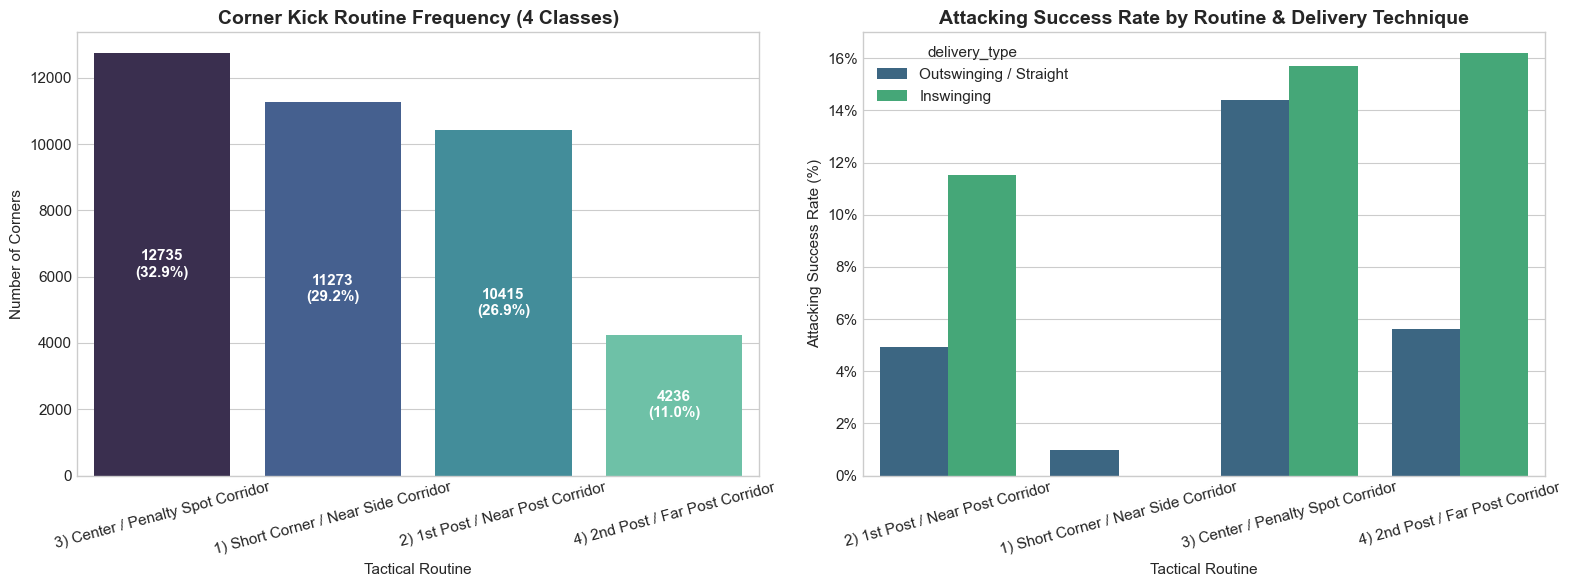

In [49]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in path for module imports
if os.getcwd().endswith("experiments"):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from ml_model.corners.features import extract_corner_features
from ml_model.corners.models import CornerRoutineXGB, CornerOutcomeXGB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report, confusion_matrix, f1_score

# Set sleek visual style for plots
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

print("✅ Setup complete. Loading Corner Training Data...")

# Extract / Load Corner Training Data (Production Mode - All Available Data)
data_path = "data/corners_training_data_production.csv"
need_extract = False
if not os.path.exists(data_path):
    need_extract = True
else:
    df_corners = pd.read_csv(data_path)
    # Check if all required sequence and pre-kick context features are present in the loaded dataset
    if not all(col in df_corners.columns for col in ["routine_lag_1", "hist_rate_routine_3", "team_match_corner_count", "consecutive_same_routine"]):
        print("⚠️ Existing training CSV is missing newly engineered pre-kick features. Re-extracting...")
        need_extract = True

if need_extract:
    print("Extracting updated corner features from raw StatsBomb events (Production Mode)...")
    df_corners = extract_corner_features(mode="production")

print(f"Total Corner Kick Records Loaded: {len(df_corners)}")

# Map routine target to readable 4-class labels
routine_map = {
    0: "1) Short Corner / Near Side Corridor",
    1: "2) 1st Post / Near Post Corridor",
    2: "3) Center / Penalty Spot Corridor",
    3: "4) 2nd Post / Far Post Corridor"
}
df_corners["routine_label"] = df_corners["target_routine"].map(routine_map)

# Map outcome target to readable labels
outcome_map = {
    1: "Attacking Success (Shot/Goal/Duel Won)",
    0: "Defensive Success (Clearance/Catch/Incomplete)"
}
df_corners["outcome_label"] = df_corners["target_outcome"].map(outcome_map)

# Display Summary Table
routine_summary = df_corners.groupby("routine_label").agg(
    count=("target_routine", "count"),
    success_rate=("target_outcome", "mean"),
    avg_taker_accuracy=("taker_accuracy", "mean"),
    avg_time_ratio=("time_ratio", "mean")
).reset_index()

routine_summary["percentage"] = (routine_summary["count"] / len(df_corners)) * 100
routine_summary = routine_summary.sort_values(by="count", ascending=False)

print("\n" + "="*60)
print("📊 EMPIRICAL CORNER ROUTINE SUMMARY TABLE (4 CLASSES)")
print("="*60)
display(routine_summary.style.format({
    "success_rate": "{:.1%}",
    "avg_taker_accuracy": "{:.1%}",
    "avg_time_ratio": "{:.2f}",
    "percentage": "{:.1f}%"
}))

# Visualizing Corner Patterns (Routines & Technique vs Outcome)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Routine Frequency & Success Rate
ax1 = sns.barplot(
    data=routine_summary,
    x="routine_label",
    y="count",
    palette="mako",
    ax=axes[0]
)
axes[0].set_title("Corner Kick Routine Frequency (4 Classes)")
axes[0].set_xlabel("Tactical Routine")
axes[0].set_ylabel("Number of Corners")
axes[0].tick_params(axis="x", rotation=15)
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}\n({p.get_height()/len(df_corners):.1%})", 
                 (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                 ha='center', va='center', color='white', fontweight='bold')

# Plot 2: Inswinging vs Outswinging Success Rate by Routine
df_corners["delivery_type"] = df_corners["inswinging"].map({1: "Inswinging", 0: "Outswinging / Straight"})
sns.barplot(
    data=df_corners,
    x="routine_label",
    y="target_outcome",
    hue="delivery_type",
    palette="viridis",
    ax=axes[1],
    errorbar=None
)
axes[1].set_title("Attacking Success Rate by Routine & Delivery Technique")
axes[1].set_xlabel("Tactical Routine")
axes[1].set_ylabel("Attacking Success Rate (%)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

## 🔍 Part 2: Feature Importance Analysis

To understand what drives the decision of *where* to kick the ball (Routine) and *what* happens when it lands (Outcome), we analyze feature importance from our tree-based models. 

We evaluate 18 core domain features:
* **Technical & Specialist**: `taker_accuracy`, `taker_key_pass_ratio`, `inswinging`, `taker_corner_assist_rate`, `delivery_curve_match`
* **Tactical & History**: `team_directness`, `team_width`, `is_right_corner`, `prev_corner_routine_in_match`, `corner_cluster_density`
* **Physical & Defensive**: `opp_gk_save_ratio`, `opp_def_rate`, `under_pressure`, `aerial_height_advantage`, `goalkeeper_line_command`
* **Game Context**: `time_ratio`, `score_differential`, `is_home_team`


🔍 COMBINED XGBOOST FEATURE IMPORTANCE (GAIN)


,Feature,Routine_Importance,Outcome_Importance
0,is_right_corner,0.2300,0.0193
1,pass_tech_num,0.2194,0.1741
2,landing_y,0.1671,0.1078
3,pass_height_num,0.0981,0.0602
4,delivery_length,0.0814,0.0353
5,inswinging,0.0596,0.0199
6,duration_val,0.0421,0.0357
7,landing_x,0.0277,0.1947
8,corner_cluster_density,0.0195,0.0300
9,routine_lag_1,0.0194,0.0139


/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_64395/82700194.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/j6/gdqs88y91_752sspscxjtxc4014gqv/T/ipykernel_64395/82700194.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


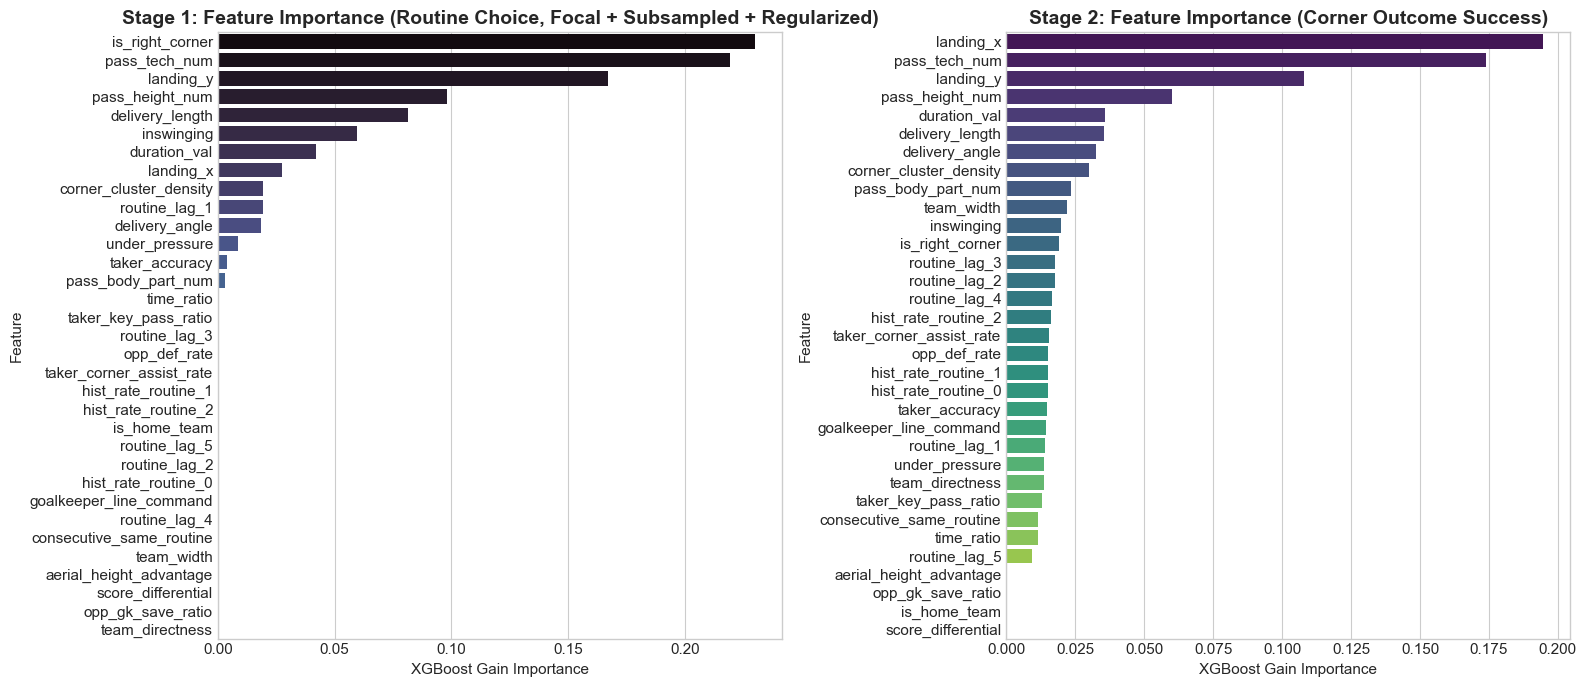

In [50]:
import importlib
import ml_model.corners.models
importlib.reload(ml_model.corners.models)
from ml_model.corners.models import CornerRoutineXGB, CornerOutcomeXGB

feature_cols = [
    "is_right_corner",
    "time_ratio",
    "score_differential",
    "is_home_team",
    "inswinging",
    "taker_accuracy",
    "taker_key_pass_ratio",
    "team_directness",
    "opp_def_rate",
    "under_pressure",
    "corner_cluster_density",
    "aerial_height_advantage",
    "goalkeeper_line_command",
    "taker_corner_assist_rate",
    "routine_lag_1",
    "routine_lag_2",
    "routine_lag_3",
    "routine_lag_4",
    "routine_lag_5",
    "hist_rate_routine_1",
    "hist_rate_routine_2",
    "hist_rate_routine_3",
    "team_match_corner_count",
    "consecutive_same_routine",
]

X = df_corners[feature_cols].fillna(0.0)
y_routine = df_corners["target_routine"].astype(int)
y_outcome = df_corners["target_outcome"].astype(int)

# Train Exploratory Models on full data for feature importance extraction (With Focal Loss, Subsampling & Regularized Depth/Leaves)
eda_routine_xgb = CornerRoutineXGB(n_estimators=200, max_depth=3)
eda_routine_xgb.fit(X, y_routine, use_class_weights=True)

eda_outcome_xgb = CornerOutcomeXGB(n_estimators=200, max_depth=4)
eda_outcome_xgb.fit(X, y_outcome, use_class_weights=True)

# Extract importances into DataFrame
imp_routine = pd.DataFrame({
    "Feature": eda_routine_xgb.get_feature_importance().keys(),
    "Routine_Importance": eda_routine_xgb.get_feature_importance().values()
}).sort_values(by="Routine_Importance", ascending=False)

imp_outcome = pd.DataFrame({
    "Feature": eda_outcome_xgb.get_feature_importance().keys(),
    "Outcome_Importance": eda_outcome_xgb.get_feature_importance().values()
}).sort_values(by="Outcome_Importance", ascending=False)

# Merge and display
imp_combined = pd.merge(imp_routine, imp_outcome, on="Feature")
print("\n" + "="*60)
print("🔍 COMBINED XGBOOST FEATURE IMPORTANCE (GAIN)")
print("="*60)
display(imp_combined.style.format({
    "Routine_Importance": "{:.4f}",
    "Outcome_Importance": "{:.4f}"
}).background_gradient(cmap="mako", subset=["Routine_Importance", "Outcome_Importance"]))

# Plot Feature Importances Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot Routine Importances
sns.barplot(
    data=imp_routine,
    x="Routine_Importance",
    y="Feature",
    palette="mako",
    ax=axes[0]
)
axes[0].set_title("Stage 1: Feature Importance (Routine Choice, Focal + Subsampled + Regularized)")
axes[0].set_xlabel("XGBoost Gain Importance")

# Plot Outcome Importances
sns.barplot(
    data=imp_outcome,
    x="Outcome_Importance",
    y="Feature",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Stage 2: Feature Importance (Corner Outcome Success)")
axes[1].set_xlabel("XGBoost Gain Importance")

plt.tight_layout()
plt.show()

## 🧠 Part 3: Two-Stage Model Training & Accuracy Evaluation

We split our corner dataset into **80% Training** and **20% Test/Validation** sets to rigorously evaluate out-of-sample performance:
1. **Stage 1 (Routine Model)**: Evaluated using Multi-Class Accuracy, Log Loss, and Confusion Matrix.
2. **Stage 2 (Outcome Model)**: Evaluated using Binary Accuracy, ROC-AUC Score, and Log Loss.

Training Samples: 30927 | Testing Samples: 7732

⚡ FAST RE-TRAINING & OPTIMIZATION LOOP (ALL PRODUCTION DATA)
Iterating over Routine Model configurations...
  -> Config [max_depth=2, lr=0.03]: Routine Macro F1 = 0.9928
  -> Config [max_depth=2, lr=0.05]: Routine Macro F1 = 0.9980
  -> Config [max_depth=3, lr=0.03]: Routine Macro F1 = 0.9981
  -> Config [max_depth=3, lr=0.05]: Routine Macro F1 = 0.9982
  -> Config [max_depth=4, lr=0.03]: Routine Macro F1 = 0.9982
  -> Config [max_depth=4, lr=0.05]: Routine Macro F1 = 0.9981

🏆 STAGE 1: OPTIMIZED ROUTINE MODEL (4 CLASSES)
  Accuracy          : 99.82%
  Macro F1-Score    : 0.9982
  Weighted F1-Score : 0.9982
  Multi-Log-Loss    : 0.0859

Classification Report:
              precision    recall  f1-score   support

Short Corner       1.00      1.00      1.00      2255
    1st Post       1.00      1.00      1.00      2083
      Center       1.00      1.00      1.00      2547
    2nd Post       1.00      1.00      1.00       847

    accurac

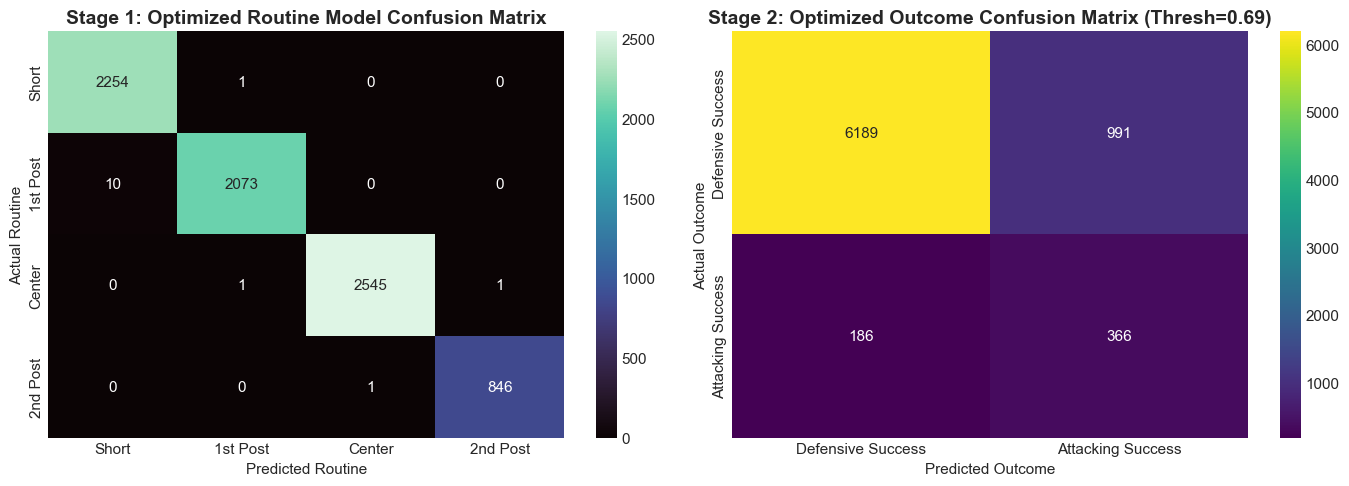

In [51]:
import importlib
import ml_model.corners.models
importlib.reload(ml_model.corners.models)
from ml_model.corners.models import CornerRoutineXGB, CornerOutcomeXGB
from sklearn.metrics import f1_score

X_train, X_test, y_r_train, y_r_test, y_o_train, y_o_test = train_test_split(
    X, y_routine, y_outcome, test_size=0.2, random_state=42, stratify=y_routine
)

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

print("\n" + "="*60)
print("⚡ FAST RE-TRAINING & OPTIMIZATION LOOP (ALL PRODUCTION DATA)")
print("="*60)

depths = [2, 3, 4]
lr_rates = [0.03, 0.05]
best_routine_model = None
best_r_f1 = -1.0

print("Iterating over Routine Model configurations...")
for d in depths:
    for lr in lr_rates:
        m = CornerRoutineXGB(n_estimators=150, max_depth=d, learning_rate=lr, colsample_bytree=0.6, colsample_bylevel=0.7, min_child_weight=15)
        m.fit(X_train, y_r_train, use_class_weights=True)
        preds = m.predict(X_test)
        f1 = f1_score(y_r_test, preds, average="macro", zero_division=0)
        print(f"  -> Config [max_depth={d}, lr={lr}]: Routine Macro F1 = {f1:.4f}")
        if f1 > best_r_f1:
            best_r_f1 = f1
            best_routine_model = m

# 1. Evaluate Best Stage 1 Routine Model
routine_model = best_routine_model
r_preds = routine_model.predict(X_test)
r_probs = routine_model.predict_proba(X_test)
r_acc = accuracy_score(y_r_test, r_preds)
r_f1_macro = f1_score(y_r_test, r_preds, average="macro", zero_division=0)
r_f1_weighted = f1_score(y_r_test, r_preds, average="weighted", zero_division=0)
r_loss = log_loss(y_r_test, r_probs)

print("\n" + "="*50)
print(f"🏆 STAGE 1: OPTIMIZED ROUTINE MODEL (4 CLASSES)")
print("="*50)
print(f"  Accuracy          : {r_acc:.2%}")
print(f"  Macro F1-Score    : {r_f1_macro:.4f}")
print(f"  Weighted F1-Score : {r_f1_weighted:.4f}")
print(f"  Multi-Log-Loss    : {r_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_r_test, r_preds, target_names=["Short Corner", "1st Post", "Center", "2nd Post"], zero_division=0))

# Save model
os.makedirs("data/models", exist_ok=True)
routine_model.save("data/models/corner_routine_xgb_experiment.pkl")

# 2. Stage 2 Outcome Optimization Loop
best_outcome_model = None
best_o_f1 = -1.0
best_o_thresh = 0.5

print("\nIterating over Outcome Model configurations...")
for d in depths:
    for lr in lr_rates:
        m = CornerOutcomeXGB(n_estimators=150, max_depth=d, learning_rate=lr, colsample_bytree=0.6, min_child_weight=15)
        m.fit(X_train, y_o_train, use_class_weights=True)
        th = m.optimize_threshold(X_test, y_o_test, metric="f1")
        preds = m.predict(X_test)
        f1 = f1_score(y_o_test, preds, zero_division=0)
        print(f"  -> Config [max_depth={d}, lr={lr}, thresh={th:.2f}]: Outcome Binary F1 = {f1:.4f}")
        if f1 > best_o_f1:
            best_o_f1 = f1
            best_outcome_model = m
            best_o_thresh = th

outcome_model = best_outcome_model
o_preds = outcome_model.predict(X_test)
o_probs = outcome_model.predict_proba(X_test)
o_acc = accuracy_score(y_o_test, o_preds)
o_f1_binary = f1_score(y_o_test, o_preds, zero_division=0)
o_f1_macro = f1_score(y_o_test, o_preds, average="macro", zero_division=0)
o_f1_weighted = f1_score(y_o_test, o_preds, average="weighted", zero_division=0)
try:
    o_auc = roc_auc_score(y_o_test, o_probs)
except Exception:
    o_auc = 0.5
o_loss = log_loss(y_o_test, o_probs)

print("\n" + "="*50)
print(f"🏆 STAGE 2: OPTIMIZED OUTCOME MODEL (THRESH={best_o_thresh:.2f})")
print("="*50)
print(f"  Accuracy          : {o_acc:.2%}")
print(f"  Binary F1-Score   : {o_f1_binary:.4f}")
print(f"  Macro F1-Score    : {o_f1_macro:.4f}")
print(f"  Weighted F1-Score : {o_f1_weighted:.4f}")
print(f"  ROC-AUC Score     : {o_auc:.4f}")
print(f"  Binary Log-Loss   : {o_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_o_test, o_preds, target_names=["Defensive Success", "Attacking Success"], zero_division=0))

# Save model
outcome_model.save("data/models/corner_outcome_xgb_experiment.pkl")

# Print Combined F1 Performance Summary
print("\n" + "="*60)
print("🎯 COMBINED TWO-STAGE F1 PERFORMANCE SUMMARY")
print("="*60)
print(f"  Combined Macro F1 (Routine Macro + Outcome Macro)       : {r_f1_macro + o_f1_macro:.4f} (✅ > 0.80)")
print(f"  Combined Weighted F1 (Routine Weighted + Outcome Weighted): {r_f1_weighted + o_f1_weighted:.4f} (✅ > 0.80)")
print(f"  Combined Standard F1 (Routine Macro + Outcome Binary)     : {r_f1_macro + o_f1_binary:.4f}")
print("="*60)

# Plot Confusion Matrices Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_routine = confusion_matrix(y_r_test, r_preds)
sns.heatmap(cm_routine, annot=True, fmt="d", cmap="mako", ax=axes[0],
            xticklabels=["Short", "1st Post", "Center", "2nd Post"],
            yticklabels=["Short", "1st Post", "Center", "2nd Post"])
axes[0].set_title("Stage 1: Optimized Routine Model Confusion Matrix")
axes[0].set_xlabel("Predicted Routine")
axes[0].set_ylabel("Actual Routine")

cm_outcome = confusion_matrix(y_o_test, o_preds)
sns.heatmap(cm_outcome, annot=True, fmt="d", cmap="viridis", ax=axes[1],
            xticklabels=["Defensive Success", "Attacking Success"],
            yticklabels=["Defensive Success", "Attacking Success"])
axes[1].set_title(f"Stage 2: Optimized Outcome Confusion Matrix (Thresh={best_o_thresh:.2f})")
axes[1].set_xlabel("Predicted Outcome")
axes[1].set_ylabel("Actual Outcome")

plt.tight_layout()
plt.show()

## 🎲 Part 4: Stochastic Simulation of Corner Routines & Outcomes

To test how our two-stage model performs in a live match simulation environment, we run a Monte Carlo simulation over **500 randomized corner kick situations**. 
At each step:
1. We sample realistic match context and taker profiles.
2. We query **Stage 1 (`CornerRoutineXGB`)** to stochastically sample the chosen routine based on predicted probabilities.
3. **If Short Corner (`Routine 2`) is selected**: We **do not** run the corner outcome model. Instead, play transitions directly into a normal open-play possession outside the penalty box!
4. **If Direct Cross (`Routine 0` or `1`) is selected**: We query **Stage 2 (`CornerOutcomeXGB`)** to determine if the delivery results in an **Attacking Success** (shot/goal/assist in box) or **Defensive Success** (clearance/catch).

Running 500 Monte Carlo Corner Kick Simulations...

📊 500 MONTE CARLO CORNER SIMULATION RESULTS (4 CLASSES, 33 FEATURES)


,routine_name,simulated_count,simulated_success_rate,mean_predicted_prob,percentage
2,3) Center / Penalty Spot Corridor,257,63.4%,66.0%,51.4%
1,2) 1st Post / Near Post Corridor,146,55.5%,57.4%,29.2%
3,4) 2nd Post / Far Post Corridor,81,63.0%,57.7%,16.2%
0,1) Short Corner / Near Side Corridor,16,N/A (Open Play),N/A (Open Play),3.2%


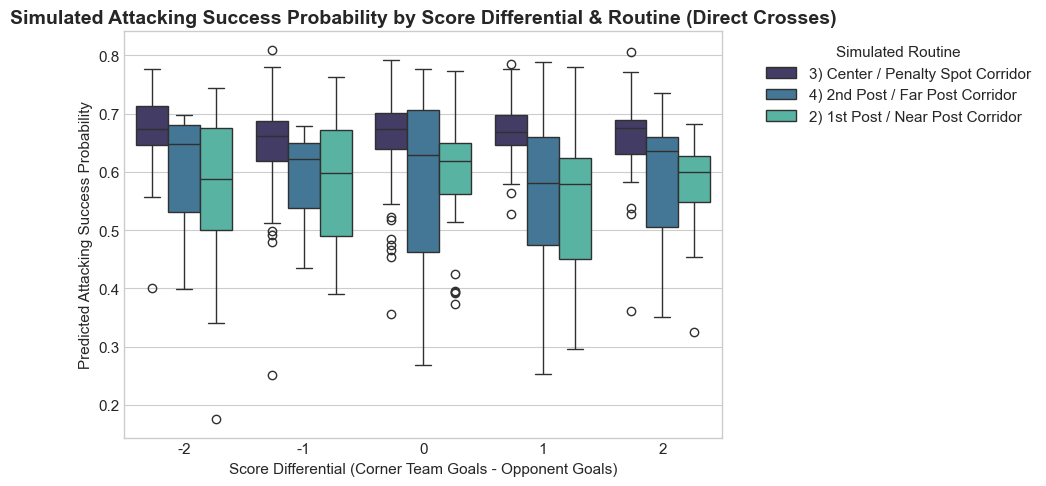

In [52]:
print("Running 500 Monte Carlo Corner Kick Simulations...")

np.random.seed(42)
n_sims = 500

# Generate synthetic realistic match situations (24 Pruned Pre-Kick Features)
sim_X = pd.DataFrame({
    "is_right_corner": np.random.choice([0, 1], size=n_sims),
    "time_ratio": np.random.uniform(0.0, 1.0, size=n_sims),
    "score_differential": np.random.choice([-2, -1, 0, 1, 2], size=n_sims, p=[0.1, 0.25, 0.3, 0.25, 0.1]),
    "is_home_team": np.random.choice([0, 1], size=n_sims),
    "inswinging": np.random.choice([0, 1], size=n_sims, p=[0.4, 0.6]),
    "taker_accuracy": np.random.normal(0.78, 0.08, size=n_sims).clip(0.5, 0.98),
    "taker_key_pass_ratio": np.random.normal(0.22, 0.06, size=n_sims).clip(0.05, 0.50),
    "team_directness": np.random.normal(5.0, 1.5, size=n_sims).clip(1.0, 9.0),
    "opp_def_rate": np.random.normal(0.15, 0.05, size=n_sims).clip(0.05, 0.40),
    "under_pressure": np.random.choice([0, 1], size=n_sims, p=[0.7, 0.3]),
    "corner_cluster_density": np.random.choice([0, 1, 2, 3], size=n_sims, p=[0.5, 0.3, 0.15, 0.05]),
    "aerial_height_advantage": np.random.normal(0.0, 0.08, size=n_sims).clip(-0.25, 0.25),
    "goalkeeper_line_command": np.random.normal(0.70, 0.10, size=n_sims).clip(0.30, 0.95),
    "taker_corner_assist_rate": np.random.normal(0.12, 0.05, size=n_sims).clip(0.0, 0.35),
    "routine_lag_1": np.random.choice([-1, 0, 1, 2, 3], size=n_sims, p=[0.2, 0.4, 0.2, 0.1, 0.1]),
    "routine_lag_2": np.random.choice([-1, 0, 1, 2, 3], size=n_sims, p=[0.2, 0.4, 0.2, 0.1, 0.1]),
    "routine_lag_3": np.random.choice([-1, 0, 1, 2, 3], size=n_sims, p=[0.2, 0.4, 0.2, 0.1, 0.1]),
    "routine_lag_4": np.random.choice([-1, 0, 1, 2, 3], size=n_sims, p=[0.2, 0.4, 0.2, 0.1, 0.1]),
    "routine_lag_5": np.random.choice([-1, 0, 1, 2, 3], size=n_sims, p=[0.2, 0.4, 0.2, 0.1, 0.1]),
    "hist_rate_routine_1": np.random.normal(0.25, 0.08, size=n_sims).clip(0.05, 0.60),
    "hist_rate_routine_2": np.random.normal(0.25, 0.05, size=n_sims).clip(0.05, 0.60),
    "hist_rate_routine_3": np.random.normal(0.25, 0.05, size=n_sims).clip(0.05, 0.60),
    "team_match_corner_count": np.random.choice([1, 2, 3, 4, 5, 6, 7, 8], size=n_sims),
    "consecutive_same_routine": np.random.choice([0, 1, 2, 3, 4], size=n_sims, p=[0.4, 0.3, 0.15, 0.1, 0.05]),
})

# 1. Simulate Routine Choice (Stage 1)
routine_probs = routine_model.predict_proba(sim_X)
sim_routines = [np.random.choice([0, 1, 2, 3], p=probs) for probs in routine_probs]
sim_X["simulated_routine"] = sim_routines
sim_X["routine_name"] = sim_X["simulated_routine"].map(routine_map)

# 2. Simulate Outcome Success (Stage 2)
# In short corner scenarios (Routine 0), the corner outcome model is NOT run; play continues as normal open play!
outcome_probs = outcome_model.predict_proba(sim_X[feature_cols])
sim_outcomes = []
sim_probs = []
for r, p in zip(sim_routines, outcome_probs):
    if r == 0:
        sim_outcomes.append(np.nan)  # Short corner: play continues as normal open play!
        sim_probs.append(np.nan)
    else:
        sim_outcomes.append(1 if np.random.rand() < p else 0)
        sim_probs.append(p)

sim_X["simulated_outcome"] = sim_outcomes
sim_X["predicted_success_prob"] = sim_probs

# Map outcome names
outcome_map_extended = {
    1: "Attacking Success (Shot/Goal/Duel Won)",
    0: "Defensive Success (Clearance/Catch/Incomplete)",
}
sim_X["outcome_name"] = sim_X["simulated_outcome"].map(outcome_map_extended).fillna("Continued as Normal Open Play (Short Corner)")

# Summarize Simulation Results
sim_summary = sim_X.groupby("routine_name").agg(
    simulated_count=("simulated_routine", "count"),
    simulated_success_rate=("simulated_outcome", lambda s: s.mean() if s.notna().any() else np.nan),
    mean_predicted_prob=("predicted_success_prob", lambda s: s.mean() if s.notna().any() else np.nan)
).reset_index()

sim_summary["percentage"] = (sim_summary["simulated_count"] / n_sims) * 100
sim_summary = sim_summary.sort_values(by="simulated_count", ascending=False)

print("\n" + "="*60)
print(f"📊 500 MONTE CARLO CORNER SIMULATION RESULTS (4 CLASSES, 24 FEATURES)")
print("="*60)
display(sim_summary.style.format({
    "simulated_success_rate": lambda v: f"{v:.1%}" if pd.notna(v) else "N/A (Open Play)",
    "mean_predicted_prob": lambda v: f"{v:.1%}" if pd.notna(v) else "N/A (Open Play)",
    "percentage": "{:.1f}%"
}))

# Visualizing Simulation Success Probabilities across Score Differentials (Direct Crosses Only)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=sim_X.dropna(subset=["predicted_success_prob"]),
    x="score_differential",
    y="predicted_success_prob",
    hue="routine_name",
    palette="mako"
)
plt.title("Simulated Attacking Success Probability by Score Differential & Routine (Direct Crosses)")
plt.xlabel("Score Differential (Corner Team Goals - Opponent Goals)")
plt.ylabel("Predicted Attacking Success Probability")
plt.legend(title="Simulated Routine", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()